In [4]:
# Cell 1 - Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import mlflow
import mlflow.sklearn
import optuna

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

BASE_DIR = Path(r'C:\Users\bisu2\Desktop\churn-prediction')

print("All libraries imported successfully ")

All libraries imported successfully 


In [5]:
# Cell 2 - Load Processed Data
X_train = np.load(BASE_DIR / 'data' / 'processed' / 'X_train.npy')
X_test  = np.load(BASE_DIR / 'data' / 'processed' / 'X_test.npy')
y_train = np.load(BASE_DIR / 'data' / 'processed' / 'y_train.npy')
y_test  = np.load(BASE_DIR / 'data' / 'processed' / 'y_test.npy')

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

print(f"\nTrain churn rate : {y_train.mean()*100:.1f}%")
print(f"Test churn rate  : {y_test.mean()*100:.1f}%")
print("\nData loaded successfully ")

X_train shape : (8278, 45)
X_test shape  : (1409, 45)
y_train shape : (8278,)
y_test shape  : (1409,)

Train churn rate : 50.0%
Test churn rate  : 26.5%

Data loaded successfully 


In [6]:
# Cell 3 - Helper Function
# Instead of writing evaluation code 4 times (once per model)
# We write it ONCE as a function and reuse it
# This is clean, professional coding

def evaluate_model(name, model, X_test, y_test):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results = {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'   : round(roc_auc_score(y_test, y_pred_prob), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4)
    }

    return results

print("Evaluation function ready ")

Evaluation function ready 


In [9]:
# Cell 4 - Train All Models
# We train 4 models and compare them
# Think of it like auditioning 4 candidates for a job
# Best performer gets selected and tuned further

models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM'            : LGBMClassifier(random_state=42, verbose=-1)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    result = evaluate_model(name, model, X_test, y_test)
    results.append(result)
    print(f"  AUC-ROC : {result['AUC-ROC']} | F1 : {result['F1 Score']} ")

print("\nAll models trained ")

Training Logistic Regression...
  AUC-ROC : 0.8402 | F1 : 0.6162 
Training Random Forest...
  AUC-ROC : 0.8141 | F1 : 0.5675 
Training XGBoost...
  AUC-ROC : 0.8192 | F1 : 0.5847 
Training LightGBM...
  AUC-ROC : 0.8325 | F1 : 0.6034 

All models trained 


MODEL COMPARISON RESULTS
              Model  Accuracy  F1 Score  AUC-ROC  Precision  Recall
Logistic Regression    0.7374    0.6162   0.8402     0.5034  0.7941
           LightGBM    0.7835    0.6034   0.8325     0.5873  0.6203
            XGBoost    0.7771    0.5847   0.8192     0.5785  0.5909
      Random Forest    0.7771    0.5675   0.8141     0.5852  0.5508


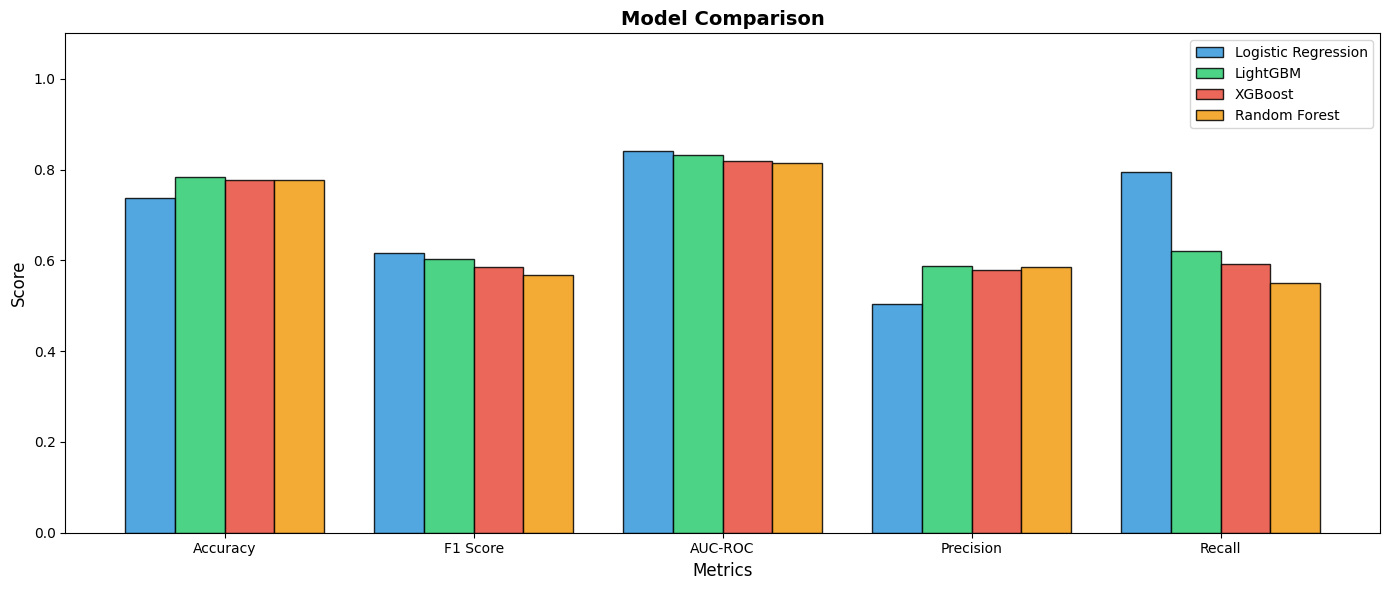


 Best Model: Logistic Regression (AUC-ROC: 0.8402)


In [10]:
# Cell 5 - Compare All Models
results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)

print("=" * 65)
print("MODEL COMPARISON RESULTS")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

# Plot comparison
metrics = ['Accuracy', 'F1 Score', 'AUC-ROC', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=row['Model'], 
           color=colors[i], alpha=0.85, edgecolor='black')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'model_comparison.png', dpi=150)
plt.show()

print(f"\n Best Model: {results_df.iloc[0]['Model']} "
      f"(AUC-ROC: {results_df.iloc[0]['AUC-ROC']})")

In [11]:
# Cell 6 - Hyperparameter Tuning with Optuna
# Optuna automatically searches for the best parameters
# Think of it like: trying different recipe variations to get best taste
# It's smarter than GridSearchCV — learns from previous attempts

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'random_state'      : 42,
        'eval_metric'       : 'logloss'
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, y_pred_prob)

print("Starting Optuna tuning (50 trials)...")
print("This will take 3-5 minutes ")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC-ROC  : {study.best_value:.4f}")
print(f"Best Params   : {study.best_params}")

Starting Optuna tuning (50 trials)...
This will take 3-5 minutes 


Best trial: 32. Best value: 0.843752: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


Best AUC-ROC  : 0.8438
Best Params   : {'n_estimators': 274, 'max_depth': 5, 'learning_rate': 0.011126522387664829, 'subsample': 0.6156169546130468, 'colsample_bytree': 0.9991454374432386, 'min_child_weight': 2}


In [12]:
# Cell 7 - Train Final Model with Best Parameters
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric']  = 'logloss'

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

final_results = evaluate_model('XGBoost (Tuned)', final_model, X_test, y_test)

print("=" * 50)
print("FINAL TUNED MODEL RESULTS")
print("=" * 50)
for metric, value in final_results.items():
    if metric != 'Model':
        print(f"  {metric:12} : {value}")
print("=" * 50)

FINAL TUNED MODEL RESULTS
  Accuracy     : 0.7736
  F1 Score     : 0.6278
  AUC-ROC      : 0.8438
  Precision    : 0.5569
  Recall       : 0.7193


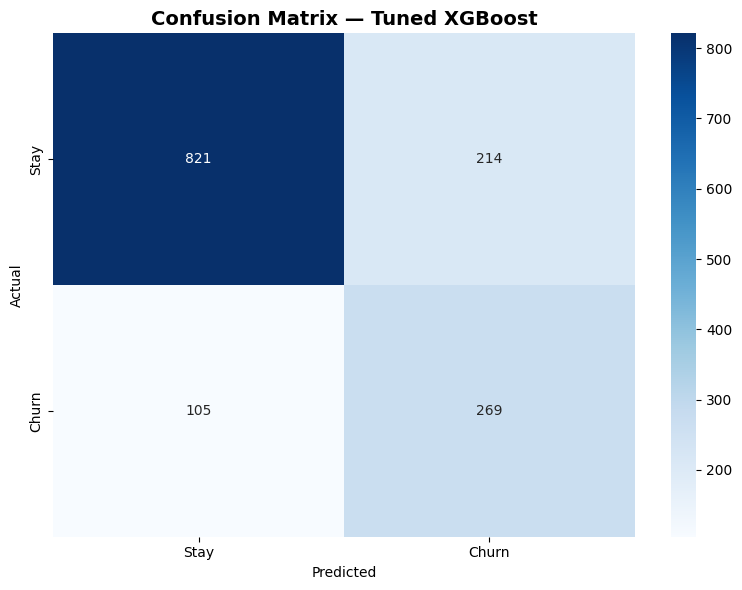


Classification Report:
              precision    recall  f1-score   support

        Stay       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [13]:
# Cell 8 - Confusion Matrix
# Confusion matrix shows exactly where model is right and wrong
# Think of it like a report card broken down by category

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix — Tuned XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

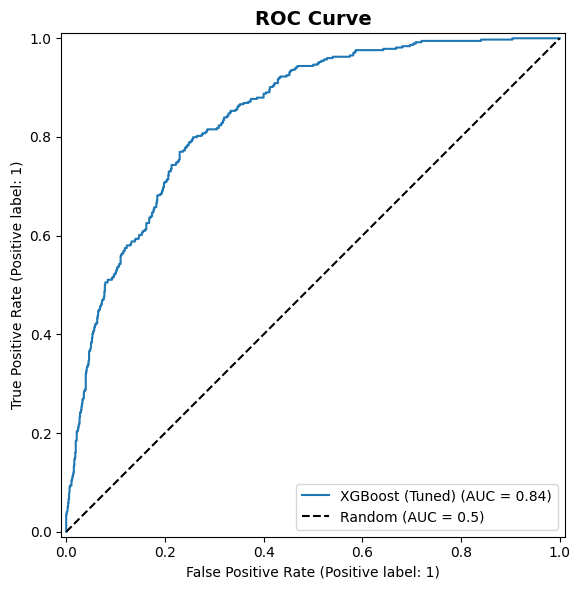

In [14]:
# Cell 9 - ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=ax, 
                                name='XGBoost (Tuned)')
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'roc_curve.png', dpi=150)
plt.show()

In [21]:
# Cell 10 - MLflow Experiment Tracking

import os

# Create mlflow directory if it doesn't exist
mlflow_dir = BASE_DIR / 'mlflow'
mlflow_dir.mkdir(exist_ok=True)

# Fix: Convert Windows path to proper URI format
mlflow_uri = mlflow_dir.as_uri()  # converts to file:///C:/Users/...
print(f"MLflow URI: {mlflow_uri}")

mlflow.set_tracking_uri(mlflow_uri)
mlflow.set_experiment('churn_prediction')

with mlflow.start_run(run_name='XGBoost_Tuned'):
    # Log parameters
    mlflow.log_params(best_params)

    # Log metrics
    mlflow.log_metric('accuracy',  final_results['Accuracy'])
    mlflow.log_metric('f1_score',  final_results['F1 Score'])
    mlflow.log_metric('auc_roc',   final_results['AUC-ROC'])
    mlflow.log_metric('precision', final_results['Precision'])
    mlflow.log_metric('recall',    final_results['Recall'])

    # Log model
    mlflow.sklearn.log_model(final_model, 'model')

    # Log plots
    mlflow.log_artifact(str(BASE_DIR / 'data' / 'processed' / 'confusion_matrix.png'))
    mlflow.log_artifact(str(BASE_DIR / 'data' / 'processed' / 'roc_curve.png'))

    run_id = mlflow.active_run().info.run_id
    print(f"MLflow Run ID: {run_id}")

print("\nExperiment logged to MLflow ")
print(f"\nTo view MLflow UI run this in terminal:")
print(f"  mlflow ui --backend-store-uri {mlflow_uri}")

2026/03/04 16:33:01 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.


MLflow URI: file:///C:/Users/bisu2/Desktop/churn-prediction/mlflow


2026/03/04 16:33:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 16:33:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Run ID: 60e8757686f64c88bbc01c908fc67ee2

Experiment logged to MLflow 

To view MLflow UI run this in terminal:
  mlflow ui --backend-store-uri file:///C:/Users/bisu2/Desktop/churn-prediction/mlflow


In [22]:
# Cell 11 - Save Final Model
model_path = BASE_DIR / 'models' / 'best_model.pkl'
joblib.dump(final_model, model_path)

print(f" Model saved to: {model_path}")
print("\nFiles in models/ folder:")
for f in (BASE_DIR / 'models').iterdir():
    print(f"  {f.name}")

 Model saved to: C:\Users\bisu2\Desktop\churn-prediction\models\best_model.pkl

Files in models/ folder:
  best_model.pkl
  categorical_cols.pkl
  numerical_cols.pkl
  preprocessor.pkl


In [23]:
# Cell 13 - Import SHAP
import shap

# Initialize SHAP JavaScript for plots
shap.initjs()

print(f"SHAP version: {shap.__version__} ")

SHAP version: 0.50.0 


In [24]:
# Cell 14 - Create SHAP Explainer
# TreeExplainer is specifically optimized for tree-based models
# like XGBoost, LightGBM, Random Forest
# It's much faster than the generic Explainer

explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for test set
# This tells us WHY the model made each prediction
print("Calculating SHAP values... ⏳")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_values.shape}")
print(f"X_test shape      : {X_test.shape}")
print("\nSHAP explainer ready ")

Calculating SHAP values... ⏳
SHAP values shape : (1409, 45)
X_test shape      : (1409, 45)

SHAP explainer ready 


In [25]:
# Cell 15 - Get Feature Names
# We need feature names to label our SHAP plots
# These come from our preprocessor we saved in Phase 2

preprocessor   = joblib.load(BASE_DIR / 'models' / 'preprocessor.pkl')
numerical_cols = joblib.load(BASE_DIR / 'models' / 'numerical_cols.pkl')
categorical_cols = joblib.load(BASE_DIR / 'models' / 'categorical_cols.pkl')

# Get feature names after OneHotEncoding
ohe_feature_names = preprocessor\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_cols)\
    .tolist()

# Combine numerical + encoded categorical names
all_feature_names = numerical_cols + ohe_feature_names

print(f"Total features after encoding : {len(all_feature_names)}")
print("\nFirst 10 feature names:")
print(all_feature_names[:10])
print("\nFeature names ready ")

Total features after encoding : 45

First 10 feature names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes']

Feature names ready 


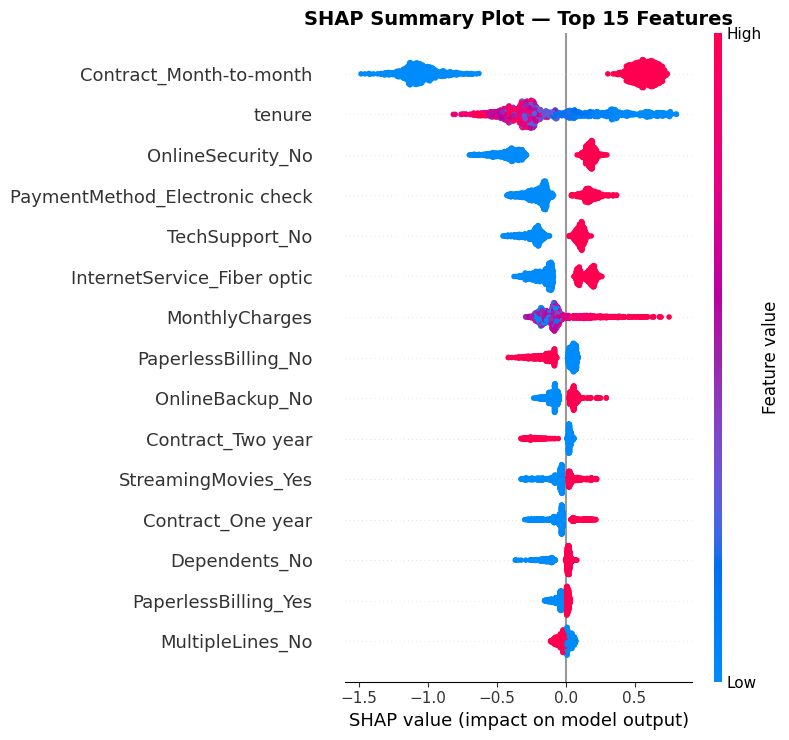

SHAP Summary Plot saved 


In [26]:
# Cell 16 - SHAP Summary Plot
# This shows ALL features and their impact on predictions
# Each dot = one customer
# Red dots  = high feature value
# Blue dots = low feature value
# X axis    = impact on churn prediction

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=all_feature_names,
    max_display=15,       # show top 15 features
    show=False
)
plt.title('SHAP Summary Plot — Top 15 Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Summary Plot saved ")

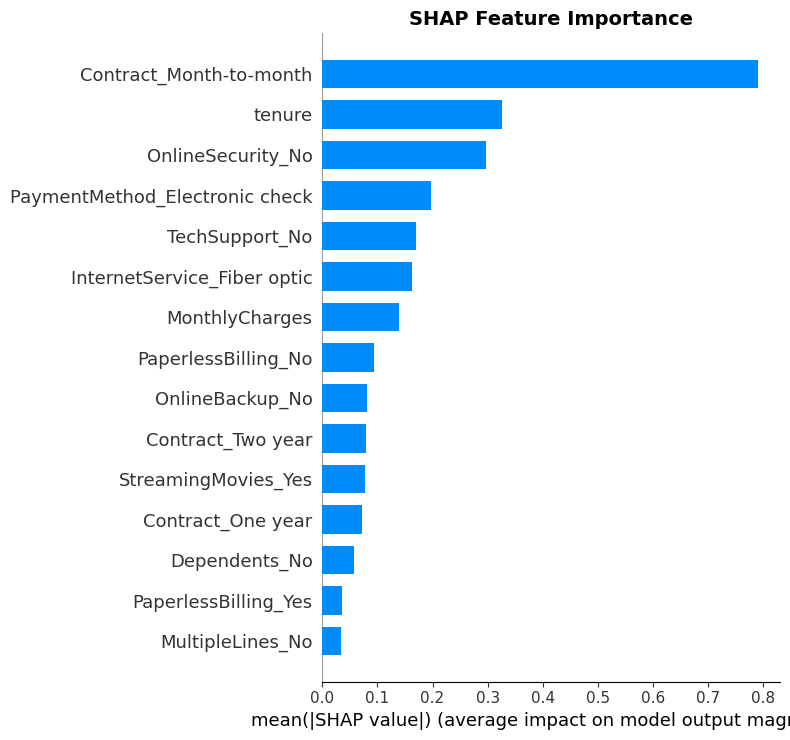

SHAP Bar Plot saved 


In [28]:
# Cell 17 - SHAP Bar Plot
# Clean, simple ranking of most important features
# Mean absolute SHAP value = average impact across all customers

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=all_feature_names,
    plot_type='bar',      # bar chart instead of dot plot
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Bar Plot saved ")

Explaining Customer #1221
Churn Probability : 90.1%
Actual Label      : Churn


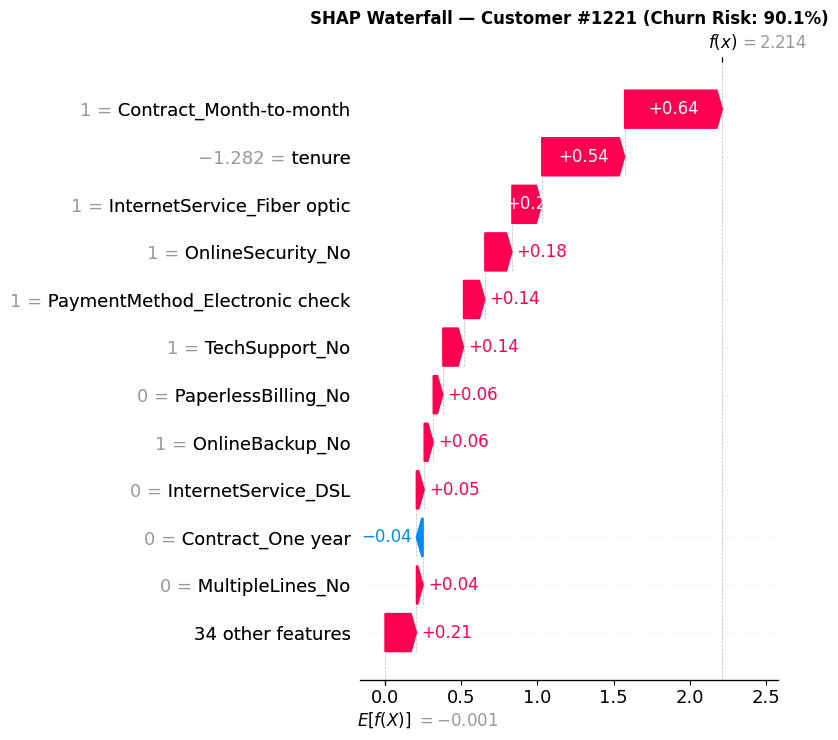

SHAP Waterfall Plot saved 


In [29]:
# Cell 18 - SHAP Waterfall Plot
# This explains ONE specific customer's prediction
# Perfect for business use case:
# "Why is customer #42 flagged as high churn risk?"

# Pick a customer who is predicted to churn
y_pred_prob = final_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(y_pred_prob)  # highest churn probability customer

print(f"Explaining Customer #{high_risk_idx}")
print(f"Churn Probability : {y_pred_prob[high_risk_idx]*100:.1f}%")
print(f"Actual Label      : {'Churn' if y_test[high_risk_idx] == 1 else 'Stay'}")

# Create SHAP explanation object
explanation = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test[high_risk_idx],
    feature_names = all_feature_names
)

# Waterfall plot
plt.figure()
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{high_risk_idx} '
          f'(Churn Risk: {y_pred_prob[high_risk_idx]*100:.1f}%)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Waterfall Plot saved ")

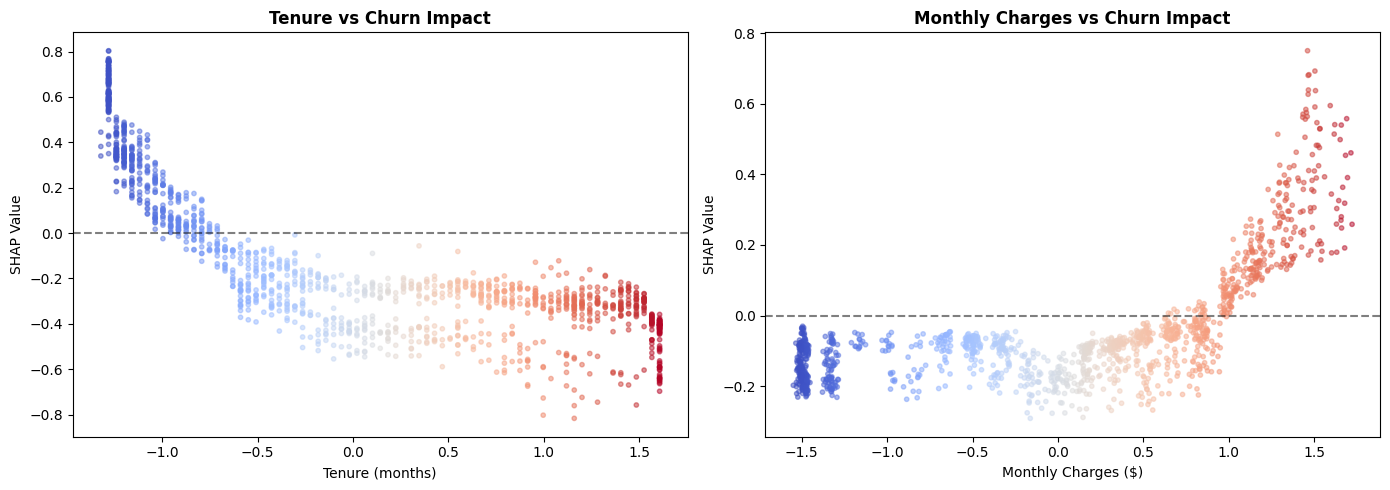

SHAP Dependence Plot saved 


In [30]:
# Cell 19 - SHAP Dependence Plot
# Shows relationship between a feature value and its SHAP impact
# Example: as tenure increases, churn probability decreases

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# tenure dependence
tenure_idx = all_feature_names.index('tenure')
axes[0].scatter(
    X_test[:, tenure_idx],
    shap_values[:, tenure_idx],
    c=X_test[:, tenure_idx],
    cmap='coolwarm', alpha=0.5, s=10
)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('SHAP Value')
axes[0].set_title('Tenure vs Churn Impact', fontweight='bold')

# MonthlyCharges dependence
monthly_idx = all_feature_names.index('MonthlyCharges')
axes[1].scatter(
    X_test[:, monthly_idx],
    shap_values[:, monthly_idx],
    c=X_test[:, monthly_idx],
    cmap='coolwarm', alpha=0.5, s=10
)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('SHAP Value')
axes[1].set_title('Monthly Charges vs Churn Impact', fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'data' / 'processed' / 'shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Dependence Plot saved ")